In [2]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from pybaselines import Baseline
from scipy.signal import savgol_filter
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score , accuracy_score, confusion_matrix, classification_report , ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import seaborn as sns
import math

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
#LOAD DATA
def load_raman_recursive(base_path, label_col_name='Label'): #Label_col ไว้เผื่อที่จะนำมาสร้าง 
    head = ['X','Y','Wave', 'Intensity']
    file_list = glob.glob(os.path.join(base_path, "**/*.txt"), recursive=True) #ค้นหาไฟล์ที่มี .txt รวมถึงโฟลเดอร์ย่อยข้างใน เเละ เก็บไว้เป็น path 
    file_list = sorted(file_list) 
    
    all_spectra = []
    for filepath in file_list:
        try:
            df = pd.read_csv(filepath, delimiter='\t', names=head, skiprows=1)
            folder_name = os.path.basename(os.path.dirname(filepath)) #ทำงานจากข้างในออกข้างนอก ตัดชื่อไฟล์ตัวสุดท้ายทิ้งไป => มองหาชื่อที่อยู่ท้ายสุด 
            df[label_col_name] = folder_name 
            df['Filename'] = os.path.basename(filepath) #เก็บชื่อไฟล์ท้ายสุด
            all_spectra.append(df)
        except:
            continue

    df_full = pd.concat(all_spectra, ignore_index=True)
    df_no_xy = df_full.drop(columns=['X', 'Y'])                
    return df_no_xy

#ENCODE DATAFRAME
def encode_df(df_cal , df_select , df_solv):
    if not df_cal.empty:
        df_cal['Target'] = df_cal['Concentration'].apply(lambda x: 'No THC' if float(x) == 0 else 'THC')

    if not df_select.empty:
        df_select['Target'] = df_select['Substance'].apply(lambda x: 'THC' if 'THC' in str(x) else 'No THC')

    if not df_solv.empty:
        df_solv['Target'] = df_solv['Solvent_Type'].apply(lambda x: 'No THC' if '0' in str(x) else 'THC')

    for df in [df_cal, df_select , df_solv]:
        if not df.empty:
            df['Target_Code'] = df['Target'].map({'No THC': 0, 'THC': 1})
        
#SORTSPECTRUM
def remove_duplicates(df):
    wave_raw = df['Wave'].to_numpy()
    intensity_raw = df['Intensity'].to_numpy()
    target_raw = df['Target_Code'].to_numpy()

    has_concentration = 'Concentration' in df.columns
    has_Substance = 'Substance' in df.columns

    if has_concentration:
        concentration_raw = df['Concentration'].to_numpy()
    if has_Substance:
        sub = df['Substance'].to_numpy()

    # หาผลต่างระหว่างจุดทั้งหมด [400, 400, 401, 402, 403, 400, 401, 402, 403]
    diffs = np.diff(wave_raw) #Example [0, 1, 1, 1, -3, 1, 1, 1]
    
    # ดึงค่าผลต่างตัวแรกที่ 'ไม่เท่ากับ 0' มาเช็คทิศทาง มากไปน้อยหรือน้อยไปมาก
    first_step = diffs[diffs != 0][0] 
    
    if first_step > 0: 
        # กรณีเรียงจากน้อยไปมาก (ผลต่างเป็นบวก)
        resets = np.where(diffs < 0)[0] #ได้เป็น index ตน.ที่เกิดการติดลบ(หาว่ามีกี่เส้น)
    else:
        # กรณีเรียงจากมากไปน้อย (ผลต่างเป็นลบ)
        resets = np.where(diffs > 0)[0]
        
    if len(resets) > 0:
        n_wav = resets[0] + 1 #เอาตำแหน่งที่เจอ (เลข 4) มาบวก 1
    else:
        n_wav = len(wave_raw)
        
    # --- เริ่มประกอบร่างข้อมูล (Reshaping & Slicing) ---
    wavenumbers = wave_raw[:n_wav] 
    intensities = intensity_raw.reshape(-1, n_wav)
    Y_labels = target_raw[::n_wav]  # สำหรับแยกคลาส 0, 1 (Classification)

    if has_concentration:
        # จัดการดึงค่า Concentration ออกมา 1 ค่าต่อ 1 พิกัด (เหมือน Y_labels)
        Concentrations = concentration_raw[::n_wav]
        return wavenumbers, intensities, Y_labels, Concentrations
    elif has_Substance:
        sub_final = sub[::n_wav]
        return wavenumbers, intensities, Y_labels, sub_final
    else:
        # กรณีมีแค่สเปกตรัมกับเฉลย 0, 1
        return wavenumbers, intensities, Y_labels

#PREPROCESSING
def preprocessing(intensity, Wave, Y_labels, Concentrations=None, snr_threshold=0.5):
    snr_list = []
    X_processed = np.zeros_like(intensity)
    fitter = Baseline(x_data=Wave)

    for i, spectrum in enumerate(intensity):

        # 1. ทำ Baseline Correction ก่อน (คำนวณจากสเปกตรัมดิบ)
        baseline, _ = fitter.drpls(spectrum, lam=1e6, eta=0.5)
        
        # 2. หักลบพื้นหลังออก เพื่อให้เหลือแค่พีก (Peak)
        baseline_corrected = spectrum - baseline 
        
        # 3. ทำ Smoothing สเปกตรัมที่ตัดพื้นหลังแล้ว
        smoothed = savgol_filter(baseline_corrected, window_length=15, polyorder=2)
        
        # 4. คำนวณ SNR (ใช้ข้อมูลที่ผ่านทั้ง baseline และ smooth แล้ว)
        snr = np.max(smoothed) / (np.std(smoothed) + 1e-9) 
        snr_list.append(snr)

        # 5. Normalize (SNV)
        normalized = (smoothed - np.mean(smoothed)) / (np.std(smoothed) + 1e-9)
        
        # หยอดข้อมูลที่เสร็จแล้วลงตาราง
        X_processed[i] = normalized

    # [ขั้นตอนที่ 4] Delete Outliers
    snr_array = np.array(snr_list)
    
    # ลองปริ้นมาดูค่า ต่ำสุด, สูงสุด และค่าเฉลี่ย
    #print(f"SNR ต่ำสุด: {np.min(snr_array):.2f}, สูงสุด: {np.max(snr_array):.2f}, เฉลี่ย: {np.mean(snr_array):.2f}")
    good_indices = snr_array > snr_threshold  # หน้ากาก (True/False)
    
    # --- เริ่มทำการหั่น (Slice) ทุกตัวแปรด้วยหน้ากากเดียวกัน ---
    intensity_final = X_processed[good_indices] 
    Y_final = Y_labels[good_indices]
    has_conc = Concentrations is not None

    filename_final = None
    

    # เช็คเงื่อนไขที่ 1: มีแค่ Concentration อย่างเดียว
    if has_conc:
        Conc_final = Concentrations[good_indices]
        return intensity_final, Y_final, Conc_final
    # เช็คเงื่อนไขที่ 2: return intensity_final , Y_final
    else:
        return intensity_final, Y_final
    
#CROP WAVE DATA 620-1700 CM-1
def crop_spectra(intensities, wavenumbers, min_wave=620, max_wave=1700):
    """
    ฟังก์ชันสำหรับตัดช่วงความยาวคลื่น (Wavenumber) ที่ไม่ต้องการทิ้ง
    """
    # 1. สร้างหน้ากาก (Mask) ตามช่วงที่กำหนด
    mask = (wavenumbers >= min_wave) & (wavenumbers <= max_wave)
    
    # 2. ใช้หน้ากากตัดทั้งแกน X (Wave) และแกน Y (Intensity)
    Wave_cropped = wavenumbers[mask]
    intensity_cropped = intensities[:, mask]
    
    # 3. ส่งข้อมูลที่ตัดแล้วกลับไปใช้งานต่อ
    return Wave_cropped, intensity_cropped

#SELECT PEAKS 
TARGET_PEAKS = [634, 645, 683, 769, 1100, 1155, 1222, 1495, 1624]
def select_peaks(X_clean, wavenumbers, target_peaks=TARGET_PEAKS):
    peak_indices = []
    wave_selected = []
    
    for p in target_peaks:
        #ชี้ตำเเหน่งที่ลบเเล้วได้ค่าน้อยที่สุด
        idx = np.argmin(np.abs(wavenumbers - p))
        peak_indices.append(idx)
        wave_selected.append(wavenumbers[idx])
        
    # ดึงเฉพาะ column ที่ตรงกับ peak
    X_selected = X_clean[:, peak_indices]
    
    return np.array(wave_selected), X_selected

#SERS MAP
def sersmap(intensity_final , Y_label):
    intensity_final = intensity_final.reshape(-1 , 25 , 1011).mean(axis = 1)
    Y_final_resized = Y_label.reshape(-1, 25)[:, 0]
    return intensity_final , Y_final_resized



In [4]:
def plot_spectra_by_concentration(df_visual, figsize=(8, 5), save_dir=None):
    """วาดกราฟสเปกตรัม Raman แยกตามความเข้มข้น (Conc)
    
    Parameters
    ----------
    df_visual  : DataFrame ที่มีคอลัมน์ wavenumber + 'Conc' (และ 'Target_Label' ถ้ามี)
    figsize    : ขนาดรูป (กว้าง, สูง) หน่วย inch
    save_dir   : path โฟลเดอร์ที่ต้องการ export PNG เช่น 'output' ถ้า None = ไม่บันทึก
    """
    unique_concs = sorted(df_visual['Conc'].unique())

    # เตรียมแกน X (wavenumber) โดยเอา metadata columns ออก
    wave_columns = df_visual.columns.drop(['Target_Label', 'Conc'], errors='ignore')
    x_values = wave_columns.astype(float)

    for conc in unique_concs:
        plt.figure(figsize=figsize)

        # ดึงเฉพาะแถวของความเข้มข้นนั้น
        df_subset = df_visual[df_visual['Conc'] == conc]
        y_values = df_subset[wave_columns].values

        # จานสี jet ตามจำนวนเส้น
        num_lines = len(df_subset)
        colors_for_lines = plt.cm.jet(np.linspace(0, 1, num_lines))
        plt.gca().set_prop_cycle(color=colors_for_lines)

        plt.plot(x_values, y_values.T, alpha=0.7, linewidth=1)

        plt.title(f"Concentration: {conc} ppm", fontsize=14, fontweight='bold', color='darkred')
        plt.xlabel('Raman shift (cm-1)', fontsize=12)
        plt.ylabel('Intensity (a.u.)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()

def plot_solvent_spectra(df_fbbb, df_acn, df_4ap , df_selectivity , figsize=(10, 6)):
    """วาดกราฟสเปกตรัม Raman แยกตามชนิด solvent (3 รูป)
    
    Parameters
    ----------
    df_fbbb        : DataFrame สเปกตรัมของ FBBB     (columns = wavenumbers, rows = samples)
    df_acn         : DataFrame สเปกตรัมของ ACN      (columns = wavenumbers, rows = samples)
    df_selectivity : DataFrame สเปกตรัม Selectivity (columns = wavenumbers, rows = samples)
    figsize        : ขนาดรูป (กว้าง, สูง) หน่วย inch
    save_dir       : path โฟลเดอร์ export PNG ถ้า None = ไม่บันทึก
    """
    # จับคู่ชื่อ title กับ DataFrame
    datasets = {
        'FBBB'       : df_fbbb,
        'ACN'        : df_acn,
        '4AP': df_4ap,
        'Selectivity' : df_selectivity
    }

    for title, df in datasets.items():
        x_values = df.columns.astype(float)   # แกน wavenumber
        y_values = df.values                   # matrix (n_samples × n_wavenumbers)

        plt.figure(figsize=figsize)

        num_lines = len(df)
        plt.gca().set_prop_cycle(
            color=plt.cm.jet(np.linspace(0, 1, num_lines))
        )

        plt.plot(x_values, y_values.T, alpha=0.7, linewidth=1)

        plt.title(title, fontsize=16, fontweight='bold', color='darkblue')
        plt.xlabel('Raman shift (cm-1)', fontsize=12)
        plt.ylabel('Intensity (a.u.)', fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()




In [5]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

def evaluate_models_leave_25_out(X_train, Y_train , class_name = None):
    n = len(X_train) // 25
    kf = KFold(n_splits=n, shuffle=False) 
    class_name = class_name
    print(f"จำนวนครั้งในการวนลูป (n_splits): {kf.get_n_splits(X_train)}\n")
    
    # 1. สร้าง Dictionary เก็บชื่อและตัวโมเดล
    # (ใส่ max_iter=2000 เผื่อ Logistic ทวนซ้ำไม่ทันจบ)
    models = {
        "1. Logistic Regression": LogisticRegression(max_iter=2000),
        "4. LDA": LinearDiscriminantAnalysis(),
        "7. Extra Trees": ExtraTreesClassifier(),
        "9. Gradient Boosting": GradientBoostingClassifier(),
        "11. Decision Tree": DecisionTreeClassifier(),
        "12. Random Forest": RandomForestClassifier(),
        "14. Ridge Classifier": RidgeClassifier(),
        "15. SVM (Kernel RBF)": SVC(kernel='rbf') 
    }
    
    # สร้างที่เก็บผลลัพธ์ Accuracy ของแต่ละโมเดล
    results = {} # สร้าง Dictionary ว่างๆ ขึ้นมาก่อน
    cm_results = {}
    # 3. วนลูปสร้างคีย์ (Key) และลิสต์ว่างๆ (List) มารอรับคะแนน
    for name in models.keys():
        results[name] = [] #"เอาชื่อโมเดลมาเป็น Key แล้วจับคู่กับลิสต์ว่างๆ"
        cm_results[name] = np.zeros((2,2) , dtype=int)

    # 2. เริ่มลูป K-Fold ทีละ 25 เส้น
    for i, (train_index, test_index) in enumerate(kf.split(X_train)):
        # โชว์เฉพาะบางรอบเพื่อไม่ให้หน้าจอรกเกินไป (เช่น โชว์รอบที่หาร 10 ลงตัว หรือรอบแรกๆ)
        if (i+1) % 10 == 0 or i == 0:
            print(f"กำลังรันรอบที่ {i+1} / {n} ... (Test Index: {test_index[0]} ถึง {test_index[-1]})")
        
        # หั่นข้อมูล Train / Test
        X_train_final, X_test_final = X_train[train_index], X_train[test_index]
        y_train_final, y_test_final = Y_train[train_index], Y_train[test_index]
        
        # 3. วนลูปเทรนและทดสอบทีละโมเดล
        for name, model in models.items():
            # สร้าง Pipeline: สเกลข้อมูล -> เข้าโมเดล
            pipeline = Pipeline([
                ('classifier', model)
            ])
            
            # สั่ง Train
            pipeline.fit(X_train_final, y_train_final)
            
            # สั่ง Predict ข้อสอบ 25 เส้น
            y_pred = pipeline.predict(X_test_final)
            
            # ตรวจคำตอบ (Accuracy) แล้วเก็บไว้
            acc = accuracy_score(y_test_final, y_pred)
            results[name].append(acc)

            cm = confusion_matrix(y_test_final, y_pred, labels=[0, 1])
            cm_results[name] += cm
            
    # 4. สรุปผลคะแนนเฉลี่ยตอนรันครบ 51 รอบ
    print("\n" + "="*50)
    print(" สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)")
    print("="*50)
    
    for name, acc_list in results.items():
        # หาค่าเฉลี่ยจากทุกๆ รอบ
        avg_acc = np.mean(acc_list)
        print(f"{name:<25}: {avg_acc * 100:.2f} %")
    
    plot_all_confusion_matrices(cm_results , class_name = class_name)
        
    return results

        
def plot_all_confusion_matrices(cm_results , class_name = None):
    
    # วนลูปตามชื่อโมเดลและตารางคะแนน
    for name, cm in cm_results.items():
        
        # 1. เอาตาราง cm มาใส่ ConfusionMatrixDisplay และกำหนดชื่อ Label
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                      display_labels=class_name)
        
        # 2. สั่งพล็อต (ถ้าชอบสีฟ้าใส่ cmap='Blues' ได้ครับ แต่ถ้าไม่ใส่จะเป็นสีมาตรฐานของ sklearn)
        disp.plot(cmap='Blues') 
        
        # 3. ใส่ชื่อบนหัวกราฟสักนิด จะได้รู้ว่ารูปนี้ของโมเดลอะไร
        plt.title(f"Confusion Matrix: {name}")
        
        # 4. โชว์กราฟ! (มันจะเด้งทีละรูปเรียงกันลงมาเลยครับ)
        plt.show()
    

def apply_pca(data , n_components=2):
    """ทำ PCA โดย Fit กับ Train Data เท่านั้น ป้องกัน Data Leakage"""
    pca = PCA(n_components=n_components)
    
    # Fit และแปลงค่าเฉพาะชุด Train
    X_train_pca = pca.fit_transform(data)
   
    
    # คำนวณเปอร์เซ็นต์ความแปรปรวน
    
    explained_variance = pca.explained_variance_ratio_ * 100
    if n_components == 2:
        print(f"PC1 อธิบายข้อมูลได้: {explained_variance[0]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[1]:.2f}%")
    else:
        print(f"PC1 อธิบายข้อมูลได้: {explained_variance[0]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[1]:.2f}%")
        print(f"PC2 อธิบายข้อมูลได้: {explained_variance[2]:.2f}%")
    return X_train_pca, pca

def plot_pca_results(X_pca, Y_labels, pca_model, title_name="Dataset" , legend_title="Label"):
    """พล็อตกราฟ Scatter Plot 2D สำหรับผลลัพธ์ PCA"""
    explained_variance = pca_model.explained_variance_ratio_ * 100
    
    plt.figure(figsize=(6, 4))
    
    # จับใส่ DataFrame ชั่วคราว
    df_plot = pd.DataFrame({
        'PC1': X_pca[:, 0], 
        'PC2': X_pca[:, 1], 
        'Target': Y_labels
    })
    
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Target', 
                    palette=['#1f77b4', '#ff7f0e'], s=80, alpha=0.8, edgecolor='k')
                    
    plt.title(f'PCA Analysis: {title_name}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)
    plt.legend(title=legend_title , loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [6]:
root = 'Datasets'

print("กำลังโหลด Calibration...")
df_cal = load_raman_recursive(os.path.join(root, 'Cal. curve (10-10-12)'), 'Concentration')

print("กำลังโหลด Selectivity...")
df_select = load_raman_recursive(os.path.join(root, 'Selectivity'), 'Substance')

print("กำลังโหลด Solvents...")
df_solv = load_raman_recursive(os.path.join(root, 'Solvents'), 'Solvent_Type')


encode_df(df_cal , df_select ,df_solv)

กำลังโหลด Calibration...
กำลังโหลด Selectivity...
กำลังโหลด Solvents...


In [7]:
df_cal.shape

(1289025, 6)

In [8]:
file_count = df_cal['Filename'].nunique()
print(f"มีไฟล์ทั้งหมด: {file_count} ไฟล์")

มีไฟล์ทั้งหมด: 51 ไฟล์


In [9]:
# 1. สร้างคอลัมน์ Solvent ก่อน
df_solv['Solvent'] = df_solv['Solvent_Type'].str.split('THC-').str[1]

# 2. แยก DataFrame
df_4ap = df_solv[df_solv['Solvent'] == '4-AP'].copy()
df_acn = df_solv[df_solv['Solvent'] == 'ACN'].copy()
df_fbbb = df_solv[df_solv['Solvent'] == 'FBBB'].copy()

In [10]:
#debug
wave_cal, intesity_cal , Y_labels_cal , Conc  = remove_duplicates(df_cal)
intensity_final, Y_final, Conc_final = preprocessing(intesity_cal , wave_cal , Y_labels_cal , Conc)
intensity_sers , Y_lll = sersmap(intensity_final , Y_final)
print(intensity_final.shape)

print(intensity_sers.shape)
print(Y_lll.shape)
wave_cal, intesity_cal , Y_labels_cal , sub= remove_duplicates(df_select)
intensity_final, Y_final = preprocessing(intesity_cal , wave_cal , Y_labels_cal )
#intensity_sers , wave_ser = sersmap(intensity_final , wave_cal)
#print(intensity_final.shape)
#print(intensity_sers.shape)
#print(intesity_cal.shape)
#print(intensity_final.shape)
#df_visual = pd.DataFrame(
    #intensity_final  , 
    #columns=np.round(wave_cal , 2) ,
   
#)

#print(df_visual.shape)
#plot_spectra_by_concentration(df_visual)

(1275, 1011)
(51, 1011)
(51,)


In [11]:
#wave_4ap, intesity_4ap, Y_labels_4ap = remove_duplicates(df_4ap)
#wave_acn, intesity_acn, Y_labels_acn = remove_duplicates(df_acn)
#wave_fbbb, intesity_fbbb, Y_labels_fbbb = remove_duplicates(df_fbbb)
#wave_select, intesity_select, Y_labels_select = remove_duplicates(df_select)

#df_visual_4ap = pd.DataFrame(intesity_4ap, columns=np.round(wave_4ap, 2))
#df_visual_acn = pd.DataFrame(intesity_acn, columns=np.round(wave_acn, 2))
#df_visual_fbbb = pd.DataFrame(intesity_fbbb, columns=np.round(wave_fbbb, 2))
#df_visual_select = pd.DataFrame(intesity_select, columns=np.round(wave_select, 2))


#plot_solvent_spectra(df_visual_fbbb, df_visual_acn, df_visual_4ap, df_visual_select)

In [12]:
#wavedebug, intensitydebug, Y_labels_debug , Conc = remove_duplicates(df_cal)
#ntensity_final, Y_final, Conc_final = preprocessing(intensitydebug , wavedebug , Y_labels_debug , Conc)
#df_visual = pd.DataFrame(
    #intensity_final, 
    #columns=np.round(wavedebug, 2)
#)
#df_visual.insert(1, 'Conc', Conc_final)
#plot_spectra_by_concentration(df_visual)

In [13]:
#wave_4ap, intesity_4ap, Y_labels_4ap = remove_duplicates(df_4ap)
#wave_acn, intesity_acn, Y_labels_acn = remove_duplicates(df_acn)
#wave_fbbb, intesity_fbbb, Y_labels_fbbb = remove_duplicates(df_fbbb)
#wave_select, intesity_select, Y_labels_select = remove_duplicates(df_select)

#intensity_4ap_final, Y_final_4ap = preprocessing(  intesity_4ap , wave_4ap , Y_labels_4ap )
#intensity_acn_final, Y_final_acn = preprocessing(  intesity_acn , wave_acn , Y_labels_acn )
#intensity_fbbb_final, Y_final_fbbb = preprocessing(  intesity_fbbb , wave_fbbb , Y_labels_fbbb )
#intensity_select_final , Y_final_select = preprocessing(  intesity_select , wave_select , Y_labels_select )

#df_visual_4ap = pd.DataFrame(intensity_4ap_final, columns=np.round(wave_4ap, 2))
#df_visual_acn = pd.DataFrame(intensity_acn_final, columns=np.round(wave_acn, 2))
#df_visual_fbbb = pd.DataFrame(intensity_fbbb_final, columns=np.round(wave_fbbb, 2))
#df_visual_select = pd.DataFrame(intensity_select_final , columns=np.round(wave_select, 2))


#plot_solvent_spectra(df_visual_fbbb, df_visual_acn, df_visual_4ap, df_visual_select)

In [14]:
"""
datasets = {
    "4-AP": df_4ap,
    "ACN": df_acn,
    "FBBB": df_fbbb,
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")

for name, df_current in datasets.items():
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)

    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

    # 4. ส่งเข้า Train/Test (ส่ง X_peaks ที่มีแค่ 9 คอลัมน์เข้าไป)

    # 5. ทำ PCA & พล็อตกราฟ
    X_train_pca, pca = apply_pca(X_peaks)
    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"Selected Peaks PCA: {name}" , legend_title="0: NO THC , 1: THC")
"""

'\ndatasets = {\n    "4-AP": df_4ap,\n    "ACN": df_acn,\n    "FBBB": df_fbbb,\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")\n\nfor name, df_current in datasets.items():\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n\n    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)\n    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)\n\n    # 4. ส่งเข้า Train/Test (ส่ง X_peaks ที่มีแค่ 9 คอลัมน์เข้าไป)\n\n    # 5. ทำ PCA & พล็อตกราฟ\n    X_train_pca, pca = apply_pca(X_peaks)\n    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"Selected Peaks PCA: {name}" , legend_title="0: NO THC , 1: THC")\n'

In [15]:
""""
datasets = {
    "4-AP": df_4ap,
    "ACN": df_acn,
    "FBBB": df_fbbb,
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")

for name, df_current in datasets.items():
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)

    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)
    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

    # 4. ส่งเข้า Train/Test (ส่ง X_peaks ที่มีแค่ 9 คอลัมน์เข้าไป)

    # 5. ทำ PCA & พล็อตกราฟ
    X_train_pca, pca = apply_pca(X_peaks)
    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"FULL SPECTRA PCA: {name}" , legend_title="0: NO THC , 1: THC")
"""

'"\ndatasets = {\n    "4-AP": df_4ap,\n    "ACN": df_acn,\n    "FBBB": df_fbbb,\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")\n\nfor name, df_current in datasets.items():\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n\n    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)\n    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n\n    # 4. ส่งเข้า Train/Test (ส่ง X_peaks ที่มีแค่ 9 คอลัมน์เข้าไป)\n\n    # 5. ทำ PCA & พล็อตกราฟ\n    X_train_pca, pca = apply_pca(X_peaks)\n    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"FULL SPECTRA PCA: {name}" , legend_title="0: NO THC , 1: THC")\n'

In [16]:
""""
datasets = {
    "4-AP": df_4ap,
    "ACN": df_acn,
    "FBBB": df_fbbb,
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")

for name, df_current in datasets.items():
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)

    #sers map
    X_peaks , Y_final = sersmap(X_clean, Y_final)

    # 5. ทำ PCA & พล็อตกราฟ
    X_train_pca, pca = apply_pca(X_peaks)
    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SERSMAP: {name}" , legend_title="0: NO THC , 1: THC")
"""

'"\ndatasets = {\n    "4-AP": df_4ap,\n    "ACN": df_acn,\n    "FBBB": df_fbbb,\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: SELECTED PEAKS (9 จุด)")\n\nfor name, df_current in datasets.items():\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n\n    #sers map\n    X_peaks , Y_final = sersmap(X_clean, Y_final)\n\n    # 5. ทำ PCA & พล็อตกราฟ\n    X_train_pca, pca = apply_pca(X_peaks)\n    plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SERSMAP: {name}" , legend_title="0: NO THC , 1: THC")\n'

In [17]:
""""
datasets = {
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: FULL SPECTRA")

for name, df_current in datasets.items():
    print(f"Name:{name}")
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    # 3. cropspectra
    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
    results = evaluate_models_leave_25_out(X_peaks, Y_final)
"""

'"\ndatasets = {\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: FULL SPECTRA")\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    # 3. cropspectra\n    Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    # 4. Model\n    results = evaluate_models_leave_25_out(X_peaks, Y_final)\n'

In [18]:
""""
datasets = {
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: Select peaks")

for name, df_current in datasets.items():
    print(f"Name:{name}")
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    # 3. cropspectra
    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)
    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
    results = evaluate_models_leave_25_out(X_peaks, Y_final)

"""

'"\ndatasets = {\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: Select peaks")\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    # 3. cropspectra\n    Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)\n    print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    # 4. Model\n    results = evaluate_models_leave_25_out(X_peaks, Y_final)\n\n'

In [19]:
def sers_leave_out(X_train, Y_train , class_name = None):
    n = len(X_train)
    kf = KFold(n_splits=n, shuffle=False) 
    class_name = class_name
    print(f"จำนวนครั้งในการวนลูป (n_splits): {kf.get_n_splits(X_train)}\n")
    
    # 1. สร้าง Dictionary เก็บชื่อและตัวโมเดล
    # (ใส่ max_iter=2000 เผื่อ Logistic ทวนซ้ำไม่ทันจบ)
    models = {
        "1. Logistic Regression": LogisticRegression(max_iter=2000),
        "4. LDA": LinearDiscriminantAnalysis(),
        "7. Extra Trees": ExtraTreesClassifier(),
        "9. Gradient Boosting": GradientBoostingClassifier(),
        "11. Decision Tree": DecisionTreeClassifier(),
        "12. Random Forest": RandomForestClassifier(),
        "14. Ridge Classifier": RidgeClassifier(),
        "15. SVM (Kernel RBF)": SVC(kernel='rbf') 
    }
    
    # สร้างที่เก็บผลลัพธ์ Accuracy ของแต่ละโมเดล
    results = {} # สร้าง Dictionary ว่างๆ ขึ้นมาก่อน
    cm_results = {}
    # 3. วนลูปสร้างคีย์ (Key) และลิสต์ว่างๆ (List) มารอรับคะแนน
    for name in models.keys():
        results[name] = [] #"เอาชื่อโมเดลมาเป็น Key แล้วจับคู่กับลิสต์ว่างๆ"
        cm_results[name] = np.zeros((2,2) , dtype=int)

    # 2. เริ่มลูป K-Fold ทีละ 25 เส้น
    for i, (train_index, test_index) in enumerate(kf.split(X_train)):
        # โชว์เฉพาะบางรอบเพื่อไม่ให้หน้าจอรกเกินไป (เช่น โชว์รอบที่หาร 10 ลงตัว หรือรอบแรกๆ)
        if (i+1) % 10 == 0 or i == 0:
            print(f"กำลังรันรอบที่ {i+1} / {n} ... (Test Index: {test_index[0]} ถึง {test_index[-1]})")
        
        # หั่นข้อมูล Train / Test
        X_train_final, X_test_final = X_train[train_index], X_train[test_index]
        y_train_final, y_test_final = Y_train[train_index], Y_train[test_index]
        
        # 3. วนลูปเทรนและทดสอบทีละโมเดล
        for name, model in models.items():
            # สร้าง Pipeline: สเกลข้อมูล -> เข้าโมเดล
            pipeline = Pipeline([
                ('classifier', model)
            ])
            
            # สั่ง Train
            pipeline.fit(X_train_final, y_train_final)
            
            # สั่ง Predict ข้อสอบ 25 เส้น
            y_pred = pipeline.predict(X_test_final)
            
            # ตรวจคำตอบ (Accuracy) แล้วเก็บไว้
            acc = accuracy_score(y_test_final, y_pred)
            results[name].append(acc)

            cm = confusion_matrix(y_test_final, y_pred, labels=[0, 1])
            cm_results[name] += cm
            
    # 4. สรุปผลคะแนนเฉลี่ยตอนรันครบ 51 รอบ
    print("\n" + "="*50)
    print(" สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)")
    print("="*50)
    
    for name, acc_list in results.items():
        # หาค่าเฉลี่ยจากทุกๆ รอบ
        avg_acc = np.mean(acc_list)
        print(f"{name:<25}: {avg_acc * 100:.2f} %")
    
    plot_all_confusion_matrices(cm_results , class_name = class_name)
        
    return results

In [20]:
def plot_pca_gradient(X_pca, Y_ppm, title_name=None):
    plt.figure(figsize=(10, 6))
    
    # c=Y_ppm คือเอาค่า 0 - 12.8 มาเป็นตัวกำหนดสี
    # cmap='Blues' คือให้ไล่สีฟ้า (ค่าน้อย=ฟ้าอ่อน, ค่ามาก=ฟ้าเข้ม)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=Y_ppm, 
                          cmap='Reds', # เปลี่ยนเป็น 'Blues', 'Reds', 'plasma' ได้ตามชอบ
                          edgecolor='black', # ใส่ขอบดำนิดนึงให้จุดดูชัดขึ้น
                          linewidth=0.5,
                          s=60, # ขนาดจุด
                          alpha=0.8) # ความโปร่งใส
    
    # เพิ่มแถบสี (Colorbar) ไว้ด้านขวา เพื่อบอกว่าสีไหนคือระดับกี่ ppm
    cbar = plt.colorbar(scatter)
    cbar.set_label('Concentration (ppm)', fontsize=12)
    
    # ตกแต่งกราฟ
    plt.title(title_name, fontsize=14, fontweight='bold')
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

In [21]:
"""""
datasets = {
    "Selectivity": df_select,
    "Real-sample": df_cal.drop(columns=['Concentration'])
}

print("🌟 เริ่มต้นรันโมเดลแบบ: Sers map")

for name, df_current in datasets.items():
    print(f"Name:{name}")
    # 1. โหลดข้อมูล (กางตาราง)
    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    # 3. cropspectra
    intensity_final , Y_final_resized = sersmap(X_clean, Y_final)
    print(f"DATA:{intensity_final.shape} Y:{Y_final_resized.shape}")
    # 4. Model
    results = sers_leave_out(intensity_final, Y_final_resized)
"""


'""\ndatasets = {\n    "Selectivity": df_select,\n    "Real-sample": df_cal.drop(columns=[\'Concentration\'])\n}\n\nprint("🌟 เริ่มต้นรันโมเดลแบบ: Sers map")\n\nfor name, df_current in datasets.items():\n    print(f"Name:{name}")\n    # 1. โหลดข้อมูล (กางตาราง)\n    wavenumbers, intensities, Y_labels = remove_duplicates(df_current)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\n    X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    # 3. cropspectra\n    intensity_final , Y_final_resized = sersmap(X_clean, Y_final)\n    print(f"DATA:{intensity_final.shape} Y:{Y_final_resized.shape}")\n    # 4. Model\n    results = sers_leave_out(intensity_final, Y_final_resized)\n'

In [22]:
""""
    # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)

Conc = np.array(Conc, dtype=float)

    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

print(Conc.shape)
print(X_peaks.shape)

X_train_pca, pca = apply_pca(X_peaks)
plot_pca_gradient(X_train_pca, Conc ,"FULL SPECTRA" )
"""



'"\n    # 1. โหลดข้อมูล (กางตาราง)\nwavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)\n\nConc = np.array(Conc, dtype=float)\n\n    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)\nWave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n\nprint(Conc.shape)\nprint(X_peaks.shape)\n\nX_train_pca, pca = apply_pca(X_peaks)\nplot_pca_gradient(X_train_pca, Conc ,"FULL SPECTRA" )\n'

In [23]:
""""
    # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)

Conc = np.array(Conc, dtype=float)

    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

print(Conc.shape)
print(X_peaks.shape)

X_train_pca, pca = apply_pca(X_peaks)
plot_pca_gradient(X_train_pca, Conc , "SELECT PEAKS")

"""


'"\n    # 1. โหลดข้อมูล (กางตาราง)\nwavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)\n\nConc = np.array(Conc, dtype=float)\n\n    # 3. 🎯 ดึงเฉพาะ 9 จุด (เอาแกน X และ Y ที่คลีนแล้วมาหั่นเอาแค่ 9 จุด)\nWave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)\n\nprint(Conc.shape)\nprint(X_peaks.shape)\n\nX_train_pca, pca = apply_pca(X_peaks)\nplot_pca_gradient(X_train_pca, Conc , "SELECT PEAKS")\n\n'

In [24]:
"""
    # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)

Conc = np.array(Conc, dtype=float)


intensity_final , Y_final_resized = sersmap(X_clean, Conc)

print(Y_final_resized.shape)
print(intensity_final .shape)

X_train_pca, pca = apply_pca(intensity_final)
plot_pca_gradient(X_train_pca, Y_final_resized , "SERSMAP")


"""

'\n    # 1. โหลดข้อมูล (กางตาราง)\nwavenumbers, intensities, Y_labels , Conc= remove_duplicates(df_cal)\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final , Conc = preprocessing(intensities, wavenumbers, Y_labels , Concentrations= Conc)\n\nConc = np.array(Conc, dtype=float)\n\n\nintensity_final , Y_final_resized = sersmap(X_clean, Conc)\n\nprint(Y_final_resized.shape)\nprint(intensity_final .shape)\n\nX_train_pca, pca = apply_pca(intensity_final)\nplot_pca_gradient(X_train_pca, Y_final_resized , "SERSMAP")\n\n\n'

In [25]:
df_select.shape

(909900, 6)

In [26]:
""""
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
print(pca_df.shape)
print(sub.shape)

plt.figure(figsize=(12, 8))

# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2',
    hue='Target_Text',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)
    style='Substance',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)
    palette={0: '#1f77b4', 1: '#d62728'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)
    s=150,               # ขนาดจุด (ปรับให้ใหญ่หน่อยจะได้เห็นรูปร่างชัดๆ)
    alpha=0.8,
    edgecolor='white'
)

# 3. ตกแต่งกราฟให้สวยงาม
plt.title('FULL SPECTRA', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)

# ดันกล่องคำอธิบาย (Legend) ไปไว้ขวามือสุด กราฟจะได้ไม่โดนบัง
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
"""

'"\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nWave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n\nX_train_pca, pca = apply_pca(X_peaks)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=[\'PC1\', \'PC2\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\nprint(pca_df.shape)\nprint(sub.shape)\n\nplt.figure(figsize=(12, 8))\n\n# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!\nsns.scatterplot(\n    data=pca_df, \n    x=\'PC1\', \n    y=\'PC2\',\n    hue=\'Target_Text\',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)\n    style=\'Substance\',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)\n    palette={0: \'#1f77b4\', 1: \'#d62728\'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)\n    s=150,               # ขนาดจุด (ปรับให้

In [27]:
"""
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks , n_components=3)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
pca_df = pd.DataFrame(X_train_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
# 2. เริ่มสร้างกราฟ 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 3. กำหนดคู่สีและรูปร่าง
color_map = {0: '#1f77b4', 1: '#d62728'} # 0=ฟ้า, 1=แดง
marker_list = ['o', '^', 's', 'D', 'P', 'X', '*'] # ลิสต์รูปร่างเผื่อไว้
unique_subs = pca_df['Substance'].unique()
# จับคู่ชื่อสารกับรูปร่างอัตโนมัติ
marker_map = {s: marker_list[i % len(marker_list)] for i, s in enumerate(unique_subs)}

# 4. วนลูปพล็อตทีละกลุ่มสาร
for target in pca_df['Target_Text'].unique():
    for substance in unique_subs:
        # กรองข้อมูลเฉพาะกลุ่มนั้นๆ
        mask = (pca_df['Target_Text'] == target) & (pca_df['Substance'] == substance)
        if mask.any(): # ถ้ามีข้อมูลกลุ่มนี้อยู่
            ax.scatter(pca_df.loc[mask, 'PC1'], 
                       pca_df.loc[mask, 'PC2'], 
                       pca_df.loc[mask, 'PC3'], 
                       c=color_map[target],          # แยกสีตาม Target (0, 1)
                       marker=marker_map[substance], # แยกทรงตาม Substance
                       s=100, alpha=0.8, edgecolors='w',
                       label=f"Target {target} | {substance}")

# 5. ตกแต่งกราฟ
ax.set_title('FULLSEPCTRA', fontsize=16, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)
ax.set_zlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)', fontsize=12)

# จัด Legend ไว้ด้านนอก
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances')

plt.tight_layout()
plt.show()
"""

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\n\n# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nWave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\n\nX_train_pca, pca = apply_pca(X_peaks , n_components=3)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=[\'PC1\', \'PC2\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\npca_df = pd.DataFrame(X_train_pca[:, :3], columns=[\'PC1\', \'PC2\', \'PC3\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\n# 2. เริ่มสร้างกราฟ 3D\nfig = plt.figure(figsize=(14, 10))\nax = fig.add_subplot(111, projection=\'3d\')\n\n# 3. กำหนดคู่สีและรูปร่าง\ncolor_

In [28]:
"""
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
print(pca_df.shape)
print(sub.shape)

plt.figure(figsize=(12, 8))

# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2',
    hue='Target_Text',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)
    style='Substance',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)
    palette={0: '#1f77b4', 1: '#d62728'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)
    s=150,               # ขนาดจุด (ปรับให้ใหญ่หน่อยจะได้เห็นรูปร่างชัดๆ)
    alpha=0.8,
    edgecolor='white'
)

# 3. ตกแต่งกราฟให้สวยงาม
plt.title('Select Peaks', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)

# ดันกล่องคำอธิบาย (Legend) ไปไว้ขวามือสุด กราฟจะได้ไม่โดนบัง
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
"""

"\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nWave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)\n\nX_train_pca, pca = apply_pca(X_peaks)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])\npca_df['Substance'] = sub\npca_df['Target_Text'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\nprint(pca_df.shape)\nprint(sub.shape)\n\nplt.figure(figsize=(12, 8))\n\n# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!\nsns.scatterplot(\n    data=pca_df, \n    x='PC1', \n    y='PC2',\n    hue='Target_Text',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)\n    style='Substance',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)\n    palette={0: '#1f77b4', 1: '#d62728'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)\n    s=150,               # ขนาดจุด (ปรับให้ใหญ่หน่อยจะได้เห็นรูป

In [29]:
""""
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks , n_components=3)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
pca_df = pd.DataFrame(X_train_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
# 2. เริ่มสร้างกราฟ 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 3. กำหนดคู่สีและรูปร่าง
color_map = {0: '#1f77b4', 1: '#d62728'} # 0=ฟ้า, 1=แดง
marker_list = ['o', '^', 's', 'D', 'P', 'X', '*'] # ลิสต์รูปร่างเผื่อไว้
unique_subs = pca_df['Substance'].unique()
# จับคู่ชื่อสารกับรูปร่างอัตโนมัติ
marker_map = {s: marker_list[i % len(marker_list)] for i, s in enumerate(unique_subs)}

# 4. วนลูปพล็อตทีละกลุ่มสาร
for target in pca_df['Target_Text'].unique():
    for substance in unique_subs:
        # กรองข้อมูลเฉพาะกลุ่มนั้นๆ
        mask = (pca_df['Target_Text'] == target) & (pca_df['Substance'] == substance)
        if mask.any(): # ถ้ามีข้อมูลกลุ่มนี้อยู่
            ax.scatter(pca_df.loc[mask, 'PC1'], 
                       pca_df.loc[mask, 'PC2'], 
                       pca_df.loc[mask, 'PC3'], 
                       c=color_map[target],          # แยกสีตาม Target (0, 1)
                       marker=marker_map[substance], # แยกทรงตาม Substance
                       s=100, alpha=0.8, edgecolors='w',
                       label=f"Target {target} | {substance}")

# 5. ตกแต่งกราฟ
ax.set_title('Select Peaks', fontsize=16, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)
ax.set_zlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)', fontsize=12)

# จัด Legend ไว้ด้านนอก
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances')

plt.tight_layout()
plt.show()
"""

'"\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\n\n# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nWave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)\n\nX_train_pca, pca = apply_pca(X_peaks , n_components=3)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=[\'PC1\', \'PC2\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\npca_df = pd.DataFrame(X_train_pca[:, :3], columns=[\'PC1\', \'PC2\', \'PC3\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\n# 2. เริ่มสร้างกราฟ 3D\nfig = plt.figure(figsize=(14, 10))\nax = fig.add_subplot(111, projection=\'3d\')\n\n# 3. กำหนดคู่สีและรูปร่าง\ncolor

In [30]:
"""
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
X_peaks , Y_final = sersmap(X_clean, Y_final)
sub = sub.reshape(-1, 25)[:, 0]

X_train_pca, pca = apply_pca(X_peaks , n_components=3)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
pca_df = pd.DataFrame(X_train_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
# 2. เริ่มสร้างกราฟ 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# 3. กำหนดคู่สีและรูปร่าง
color_map = {0: '#1f77b4', 1: '#d62728'} # 0=ฟ้า, 1=แดง
marker_list = ['o', '^', 's', 'D', 'P', 'X', '*'] # ลิสต์รูปร่างเผื่อไว้
unique_subs = pca_df['Substance'].unique()
# จับคู่ชื่อสารกับรูปร่างอัตโนมัติ
marker_map = {s: marker_list[i % len(marker_list)] for i, s in enumerate(unique_subs)}

# 4. วนลูปพล็อตทีละกลุ่มสาร
for target in pca_df['Target_Text'].unique():
    for substance in unique_subs:
        # กรองข้อมูลเฉพาะกลุ่มนั้นๆ
        mask = (pca_df['Target_Text'] == target) & (pca_df['Substance'] == substance)
        if mask.any(): # ถ้ามีข้อมูลกลุ่มนี้อยู่
            ax.scatter(pca_df.loc[mask, 'PC1'], 
                       pca_df.loc[mask, 'PC2'], 
                       pca_df.loc[mask, 'PC3'], 
                       c=color_map[target],          # แยกสีตาม Target (0, 1)
                       marker=marker_map[substance], # แยกทรงตาม Substance
                       s=100, alpha=0.8, edgecolors='w',
                       label=f"Target {target} | {substance}")

# 5. ตกแต่งกราฟ
ax.set_title('Sersmap', fontsize=16, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
ax.set_ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)
ax.set_zlabel(f'Principal Component 3 ({explained_variance[2]:.2f}%)', fontsize=12)

# จัด Legend ไว้ด้านนอก
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances')

plt.tight_layout()
plt.show()
"""

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\n\n# 1. ดึงข้อมูล PCA มา 3 แกน (PC1, PC2, PC3)\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nX_peaks , Y_final = sersmap(X_clean, Y_final)\nsub = sub.reshape(-1, 25)[:, 0]\n\nX_train_pca, pca = apply_pca(X_peaks , n_components=3)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=[\'PC1\', \'PC2\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\npca_df = pd.DataFrame(X_train_pca[:, :3], columns=[\'PC1\', \'PC2\', \'PC3\'])\npca_df[\'Substance\'] = sub\npca_df[\'Target_Text\'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\n# 2. เริ่มสร้างกราฟ 3D\nfig = plt.figure(figsize=(14, 10))\nax = fig.add_subplot(111, projection=\'3d\')\n\n# 3. กำหนดค

In [31]:
"""
wavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)
    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
X_peaks , Y_final = sersmap(X_clean, Y_final)
sub = sub.reshape(-1, 25)[:, 0]

X_train_pca, pca = apply_pca(X_peaks)
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Substance'] = sub
pca_df['Target_Text'] = Y_final
explained_variance = pca.explained_variance_ratio_ * 100
print(pca_df.shape)
print(sub.shape)

plt.figure(figsize=(12, 8))

# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2',
    hue='Target_Text',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)
    style='Substance',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)
    palette={0: '#1f77b4', 1: '#d62728'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)
    s=150,               # ขนาดจุด (ปรับให้ใหญ่หน่อยจะได้เห็นรูปร่างชัดๆ)
    alpha=0.8,
    edgecolor='white'
)

# 3. ตกแต่งกราฟให้สวยงาม
plt.title('Sers map', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2f}%)', fontsize=12)

# ดันกล่องคำอธิบาย (Legend) ไปไว้ขวามือสุด กราฟจะได้ไม่โดนบัง
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Groups & Substances', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

"""

"\nwavenumbers, intensities, Y_labels , sub = remove_duplicates(df_select)\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n    #sers map\nX_peaks , Y_final = sersmap(X_clean, Y_final)\nsub = sub.reshape(-1, 25)[:, 0]\n\nX_train_pca, pca = apply_pca(X_peaks)\npca_df = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])\npca_df['Substance'] = sub\npca_df['Target_Text'] = Y_final\nexplained_variance = pca.explained_variance_ratio_ * 100\nprint(pca_df.shape)\nprint(sub.shape)\n\nplt.figure(figsize=(12, 8))\n\n# 🌟 ไฮไลท์อยู่ตรงนี้ครับ!\nsns.scatterplot(\n    data=pca_df, \n    x='PC1', \n    y='PC2',\n    hue='Target_Text',   # 🎨 แบ่งสีหลักตามกลุ่ม (เช่น NO THC=ฟ้า, THC=ส้ม)\n    style='Substance',   # 🔺 แบ่งรูปร่างตามชื่อสาร (เช่น 0ppm=วงกลม, CBD=กากบาท)\n    palette={0: '#1f77b4', 1: '#d62728'}, # ฟิกซ์สีให้ชัด (NO THC=น้ำเงิน, THC=แดง)\n    s=150,               # ขนาดจุด (ปรับให

In [32]:
df_cal_Threshold = df_cal.copy()

In [33]:
if not df_cal_Threshold.empty:
    df_cal_Threshold['Target'] = df_cal_Threshold['Concentration'].apply(lambda x: 'less6.4' if float(x) <= 6.4 else 'more6.4' )
    df_cal_Threshold['Target_Code'] = df_cal_Threshold['Target'].map({'less6.4': 0, 'more6.4': 1})

In [34]:
df_cal_Threshold.head()

,Wave,Intensity,Concentration,Filename,Target,Target_Code
0,1723.380859,5142.324707,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
1,1722.401367,5211.229492,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
2,1721.421875,5194.927246,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
3,1720.441406,5247.508789,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0
4,1719.460938,5249.058594,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less6.4,0


PC1 อธิบายข้อมูลได้: 58.15%
PC2 อธิบายข้อมูลได้: 12.57%


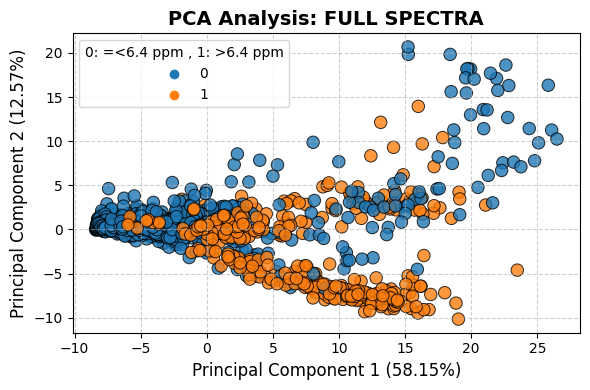

In [35]:

df_single = df_cal_Threshold.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)

 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"FULL SPECTRA" , legend_title="0: =<6.4 ppm , 1: >6.4 ppm")

PC1 อธิบายข้อมูลได้: 80.49%
PC2 อธิบายข้อมูลได้: 7.96%


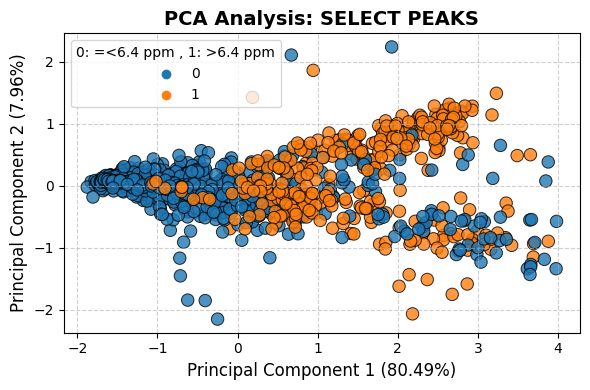

In [36]:

df_single = df_cal_Threshold.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)

 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SELECT PEAKS" , legend_title="0: =<6.4 ppm , 1: >6.4 ppm")

PC1 อธิบายข้อมูลได้: 69.31%
PC2 อธิบายข้อมูลได้: 12.15%


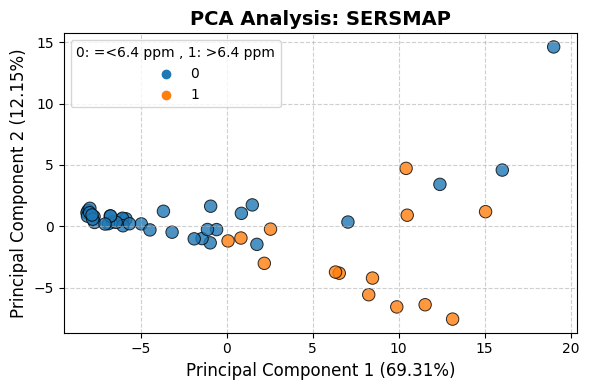

In [37]:

df_single = df_cal_Threshold.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)

 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
X_peaks , Y_final = sersmap(X_clean, Y_labels)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SERSMAP" , legend_title="0: =<6.4 ppm , 1: >6.4 ppm")

In [38]:
df_cal_Threshold_32 = df_cal.copy()

In [39]:
if not df_cal_Threshold_32.empty:
    df_cal_Threshold_32['Target'] = df_cal_Threshold_32['Concentration'].apply(lambda x: 'less3.2' if float(x) <= 3.2 else 'more3.2' )
    df_cal_Threshold_32['Target_Code'] = df_cal_Threshold_32['Target'].map({'less3.2': 0, 'more3.2': 1})

In [40]:
df_cal_Threshold_32.head()

,Wave,Intensity,Concentration,Filename,Target,Target_Code
0,1723.380859,5142.324707,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less3.2,0
1,1722.401367,5211.229492,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less3.2,0
2,1721.421875,5194.927246,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less3.2,0
3,1720.441406,5247.508789,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less3.2,0
4,1719.460938,5249.058594,0.8,20260131-(10-10-12) 0.8 ppm THC-DEK42 Original...,less3.2,0


525
PC1 อธิบายข้อมูลได้: 58.15%
PC2 อธิบายข้อมูลได้: 12.57%


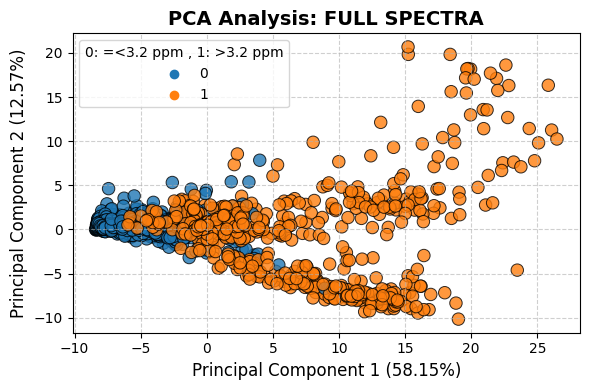

In [41]:
df_single = df_cal_Threshold_32.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)
count = (Y_labels == 1).sum()
print(count)
 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"FULL SPECTRA" , legend_title="0: =<3.2 ppm , 1: >3.2 ppm")

PC1 อธิบายข้อมูลได้: 80.49%
PC2 อธิบายข้อมูลได้: 7.96%


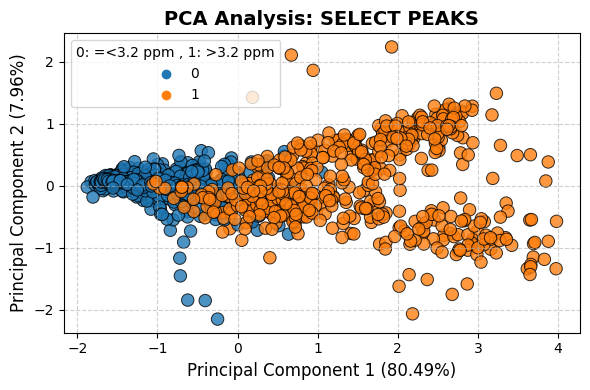

In [42]:

df_single = df_cal_Threshold_32.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)

 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SELECT PEAKS" , legend_title="0: =<3.2 ppm , 1: >3.2 ppm")

(51, 1011)
PC1 อธิบายข้อมูลได้: 69.31%
PC2 อธิบายข้อมูลได้: 12.15%


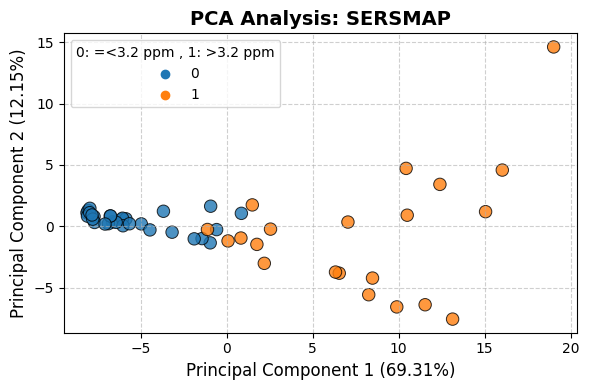

In [43]:

df_single = df_cal_Threshold_32.drop(columns=['Concentration'])

# 1. จัดโครงสร้างข้อมูล
wavenumbers, intensities, Y_labels = remove_duplicates(df_single)

 # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
    #sers map
X_peaks , Y_final = sersmap(X_clean, Y_labels)
print(X_peaks.shape)

X_train_pca, pca = apply_pca(X_peaks)

# 6. พล็อตกราฟ (Title จะโชว์ว่า "Selectivity Training Set")
plot_pca_results(X_train_pca, Y_final , pca, title_name=f"SERSMAP" , legend_title="0: =<3.2 ppm , 1: >3.2 ppm")

In [45]:
"""    
#  1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = evaluate_models_leave_25_out(X_peaks, Y_final , class_name = ['<= 6.4 ppm (0)', '> 6.4 ppm (1)'])
"""

'    \n#  1. โหลดข้อมูล (กางตาราง)\nwavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=[\'Concentration\']))\n\n    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)\nX_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)\n   # 3. cropspectra\nWave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)\nprint(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")\n    # 4. Model\nresults = evaluate_models_leave_25_out(X_peaks, Y_final , class_name = [\'<= 6.4 ppm (0)\', \'> 6.4 ppm (1)\'])\n'

DATA:(1275, 9) Y:(1275,)
จำนวนครั้งในการวนลูป (n_splits): 51

กำลังรันรอบที่ 1 / 51 ... (Test Index: 0 ถึง 24)
กำลังรันรอบที่ 10 / 51 ... (Test Index: 225 ถึง 249)
กำลังรันรอบที่ 20 / 51 ... (Test Index: 475 ถึง 499)
กำลังรันรอบที่ 30 / 51 ... (Test Index: 725 ถึง 749)
กำลังรันรอบที่ 40 / 51 ... (Test Index: 975 ถึง 999)
กำลังรันรอบที่ 50 / 51 ... (Test Index: 1225 ถึง 1249)

 สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)
1. Logistic Regression   : 83.29 %
4. LDA                   : 83.53 %
7. Extra Trees           : 87.76 %
9. Gradient Boosting     : 86.35 %
11. Decision Tree        : 81.73 %
12. Random Forest        : 86.59 %
14. Ridge Classifier     : 83.69 %
15. SVM (Kernel RBF)     : 86.90 %


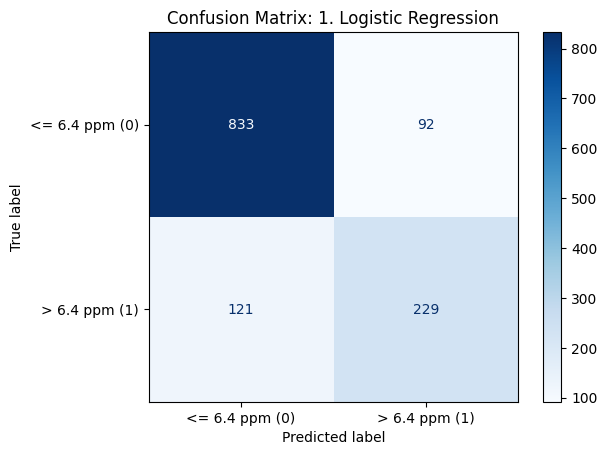

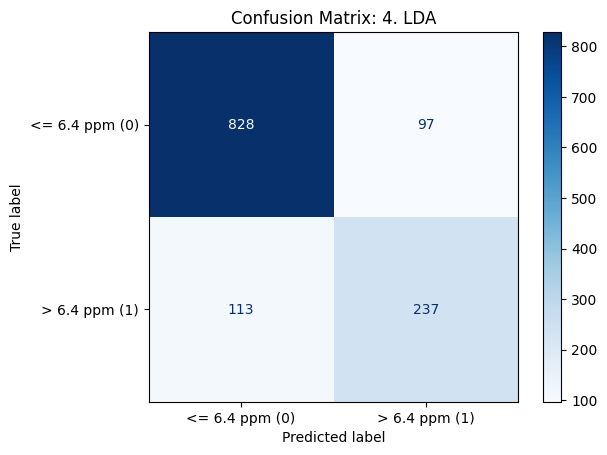

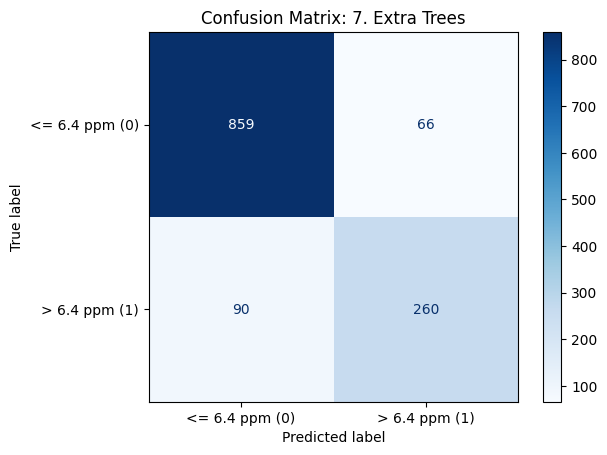

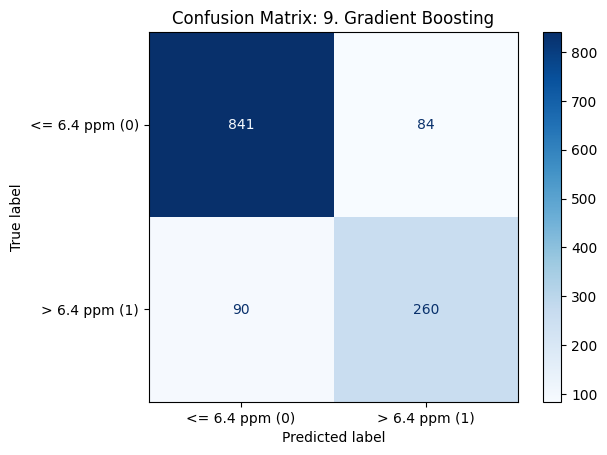

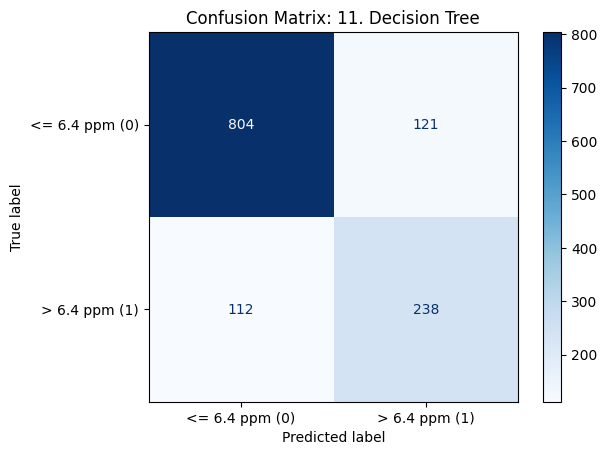

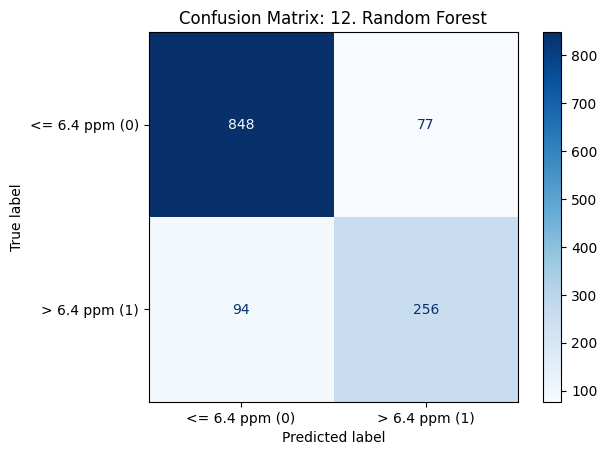

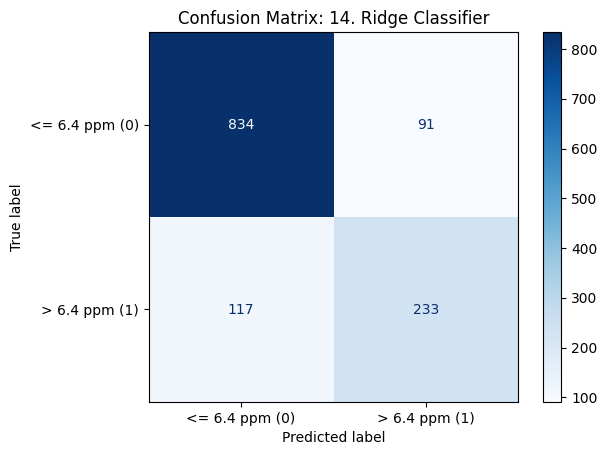

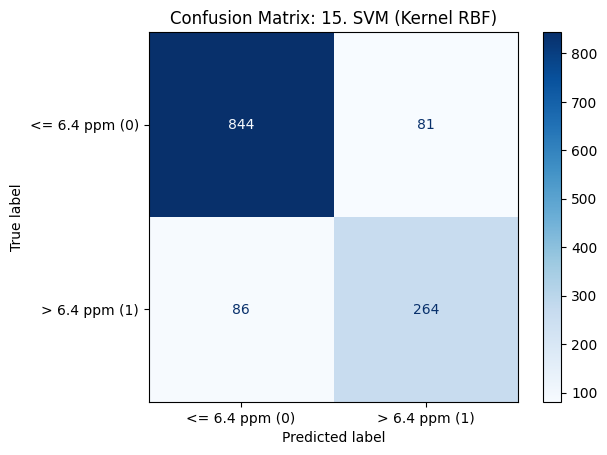

In [46]:
    # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = evaluate_models_leave_25_out(X_peaks, Y_final , class_name = ['<= 6.4 ppm (0)', '> 6.4 ppm (1)'])

DATA:(51, 1011) Y:(51,)
จำนวนครั้งในการวนลูป (n_splits): 51

กำลังรันรอบที่ 1 / 51 ... (Test Index: 0 ถึง 0)
กำลังรันรอบที่ 10 / 51 ... (Test Index: 9 ถึง 9)
กำลังรันรอบที่ 20 / 51 ... (Test Index: 19 ถึง 19)
กำลังรันรอบที่ 30 / 51 ... (Test Index: 29 ถึง 29)
กำลังรันรอบที่ 40 / 51 ... (Test Index: 39 ถึง 39)
กำลังรันรอบที่ 50 / 51 ... (Test Index: 49 ถึง 49)

 สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)
1. Logistic Regression   : 94.12 %
4. LDA                   : 90.20 %
7. Extra Trees           : 86.27 %
9. Gradient Boosting     : 86.27 %
11. Decision Tree        : 82.35 %
12. Random Forest        : 88.24 %
14. Ridge Classifier     : 94.12 %
15. SVM (Kernel RBF)     : 84.31 %


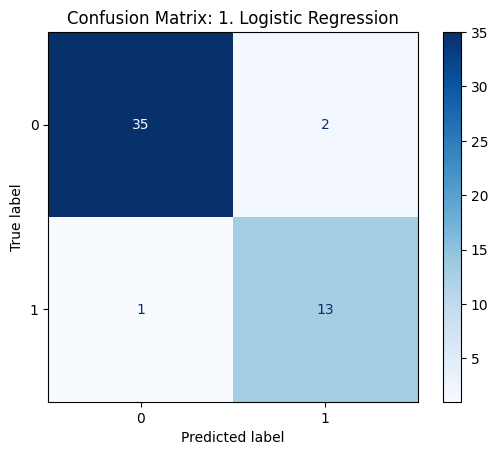

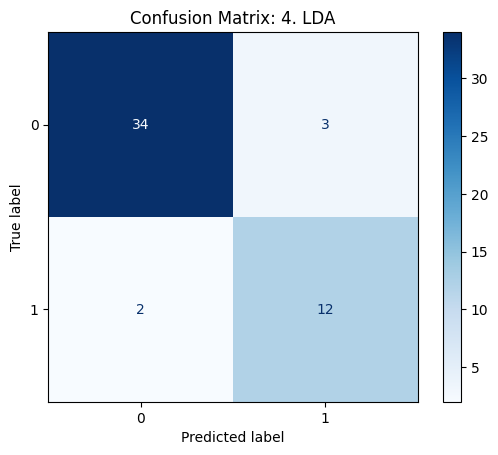

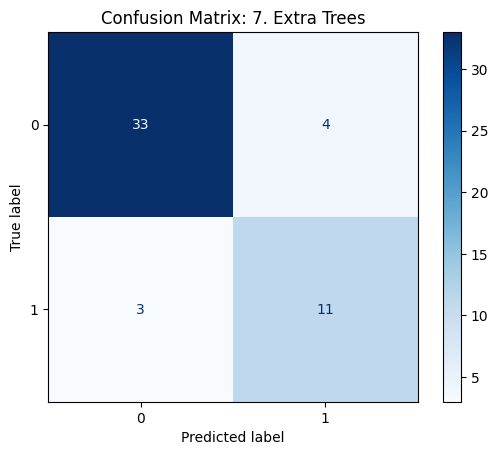

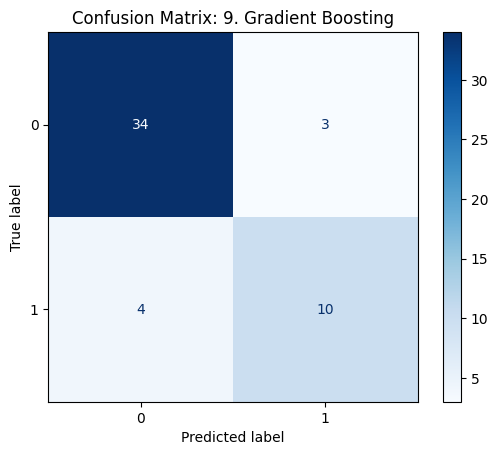

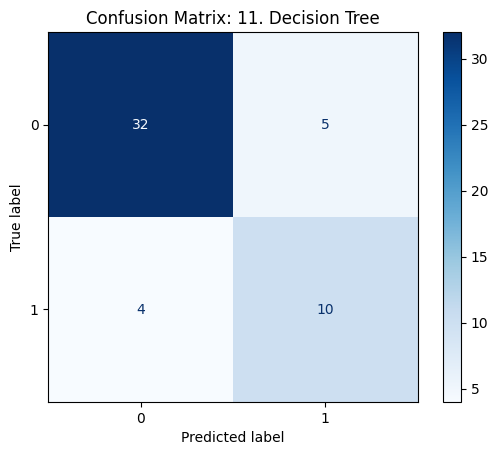

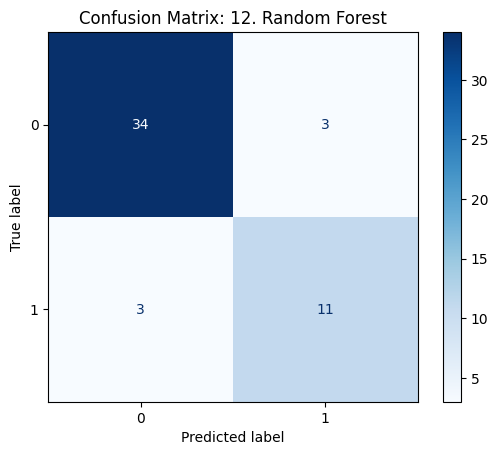

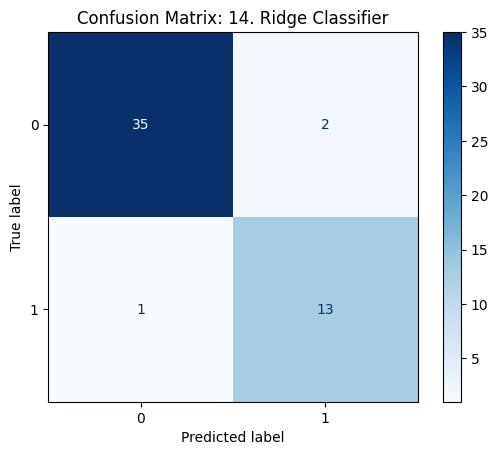

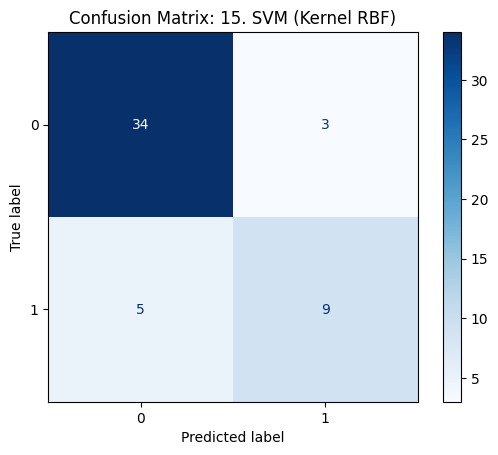

In [ ]:
"""
   # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
X_peaks , Y_final = sersmap(X_clean, Y_final)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = sers_leave_out(X_peaks, Y_final , class_name = ['<= 6.4 ppm (0)', '> 6.4 ppm (1)'])
"""

DATA:(1275, 987) Y:(1275,)
จำนวนครั้งในการวนลูป (n_splits): 51

กำลังรันรอบที่ 1 / 51 ... (Test Index: 0 ถึง 24)
กำลังรันรอบที่ 10 / 51 ... (Test Index: 225 ถึง 249)
กำลังรันรอบที่ 20 / 51 ... (Test Index: 475 ถึง 499)
กำลังรันรอบที่ 30 / 51 ... (Test Index: 725 ถึง 749)
กำลังรันรอบที่ 40 / 51 ... (Test Index: 975 ถึง 999)
กำลังรันรอบที่ 50 / 51 ... (Test Index: 1225 ถึง 1249)

 สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)
1. Logistic Regression   : 96.08 %
4. LDA                   : 81.80 %
7. Extra Trees           : 94.59 %
9. Gradient Boosting     : 94.20 %
11. Decision Tree        : 92.47 %
12. Random Forest        : 94.12 %
14. Ridge Classifier     : 95.37 %
15. SVM (Kernel RBF)     : 91.92 %


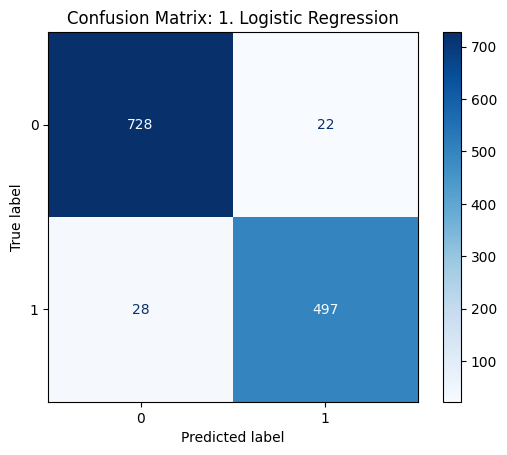

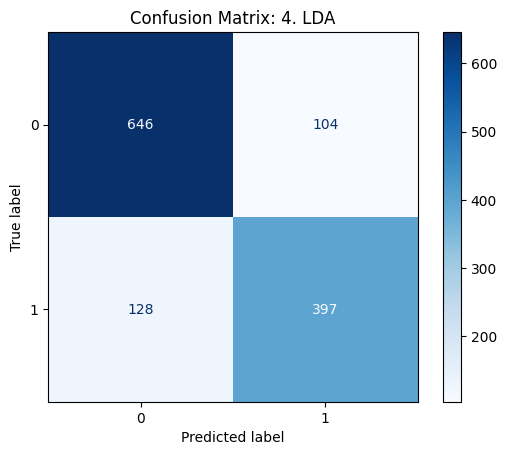

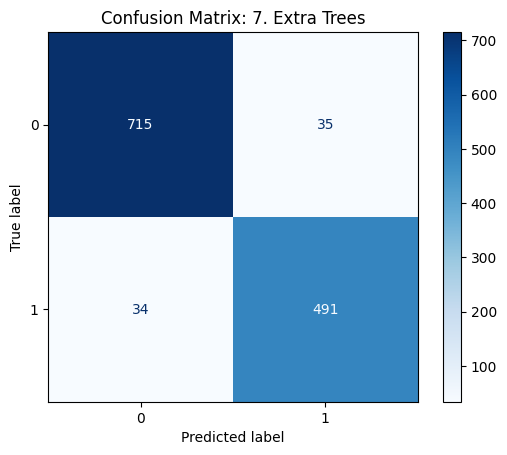

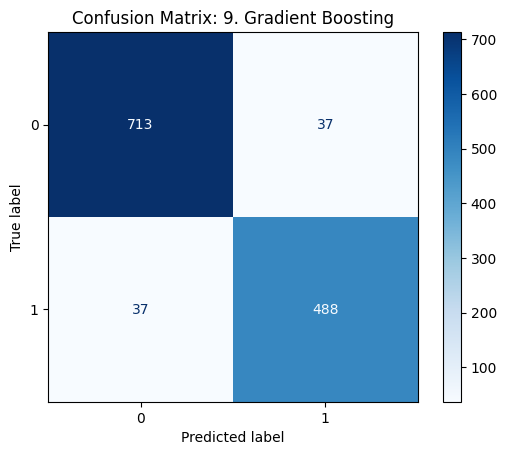

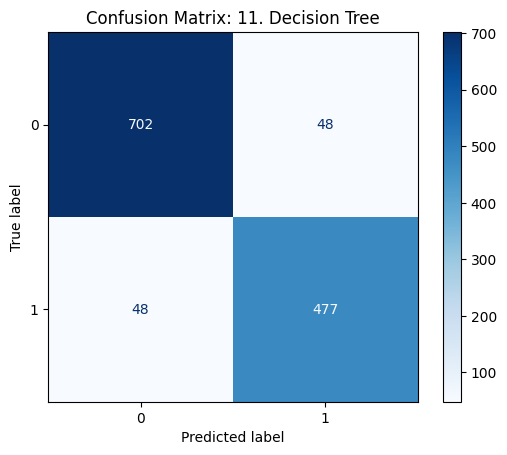

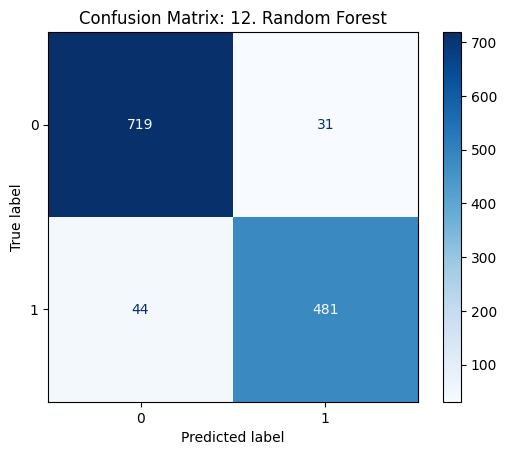

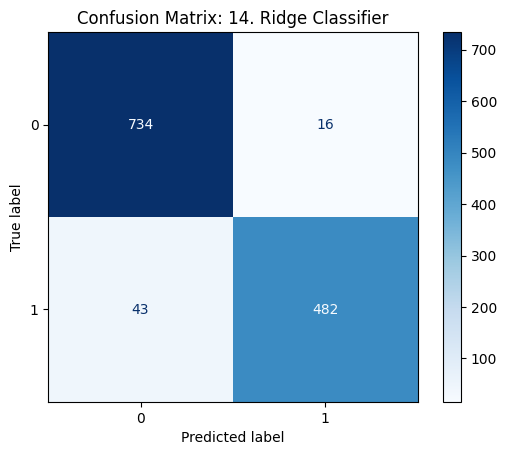

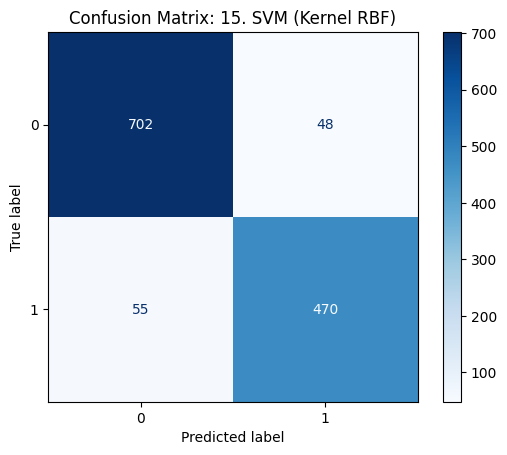

In [ ]:
 
""""
   # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold_32.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
Wave_peaks, X_peaks = crop_spectra(X_clean, wavenumbers)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = evaluate_models_leave_25_out(X_peaks, Y_final , class_name = ['<= 3.2 ppm (0)', '> 3.2 ppm (1)'])
""""

DATA:(1275, 9) Y:(1275,)
จำนวนครั้งในการวนลูป (n_splits): 51

กำลังรันรอบที่ 1 / 51 ... (Test Index: 0 ถึง 24)
กำลังรันรอบที่ 10 / 51 ... (Test Index: 225 ถึง 249)
กำลังรันรอบที่ 20 / 51 ... (Test Index: 475 ถึง 499)
กำลังรันรอบที่ 30 / 51 ... (Test Index: 725 ถึง 749)
กำลังรันรอบที่ 40 / 51 ... (Test Index: 975 ถึง 999)
กำลังรันรอบที่ 50 / 51 ... (Test Index: 1225 ถึง 1249)

 สรุปผลความแม่นยำเฉลี่ย (Average Accuracy)
1. Logistic Regression   : 91.45 %
4. LDA                   : 90.90 %
7. Extra Trees           : 93.02 %
9. Gradient Boosting     : 91.69 %
11. Decision Tree        : 89.65 %
12. Random Forest        : 91.76 %
14. Ridge Classifier     : 90.82 %
15. SVM (Kernel RBF)     : 91.22 %


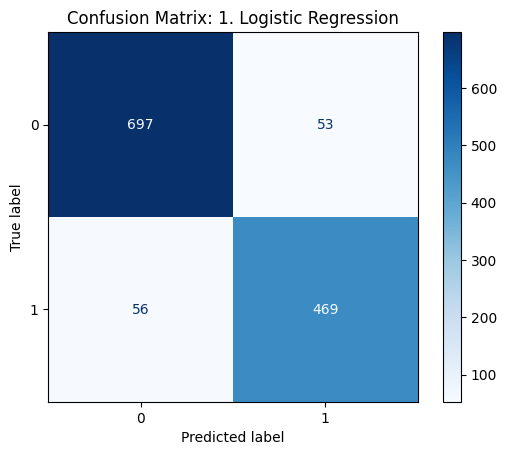

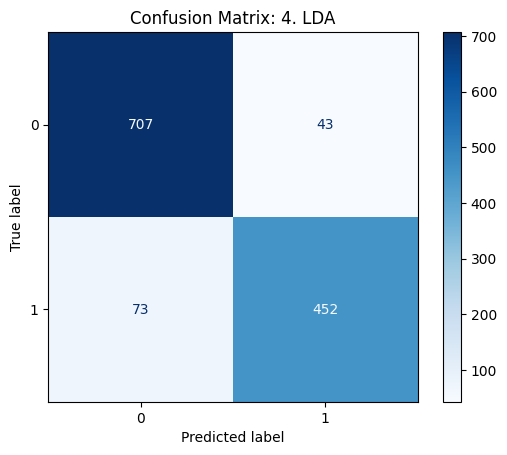

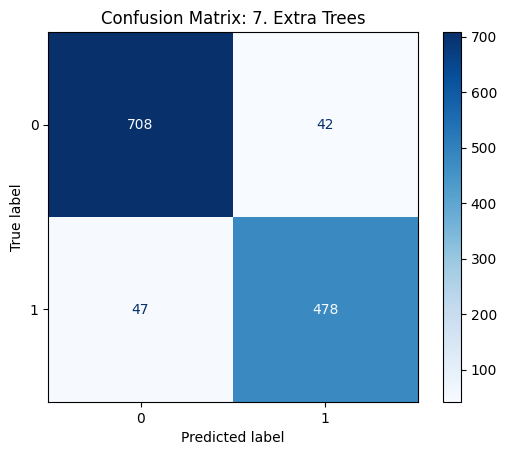

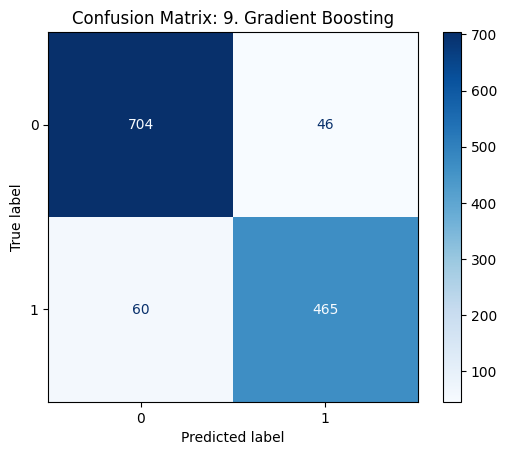

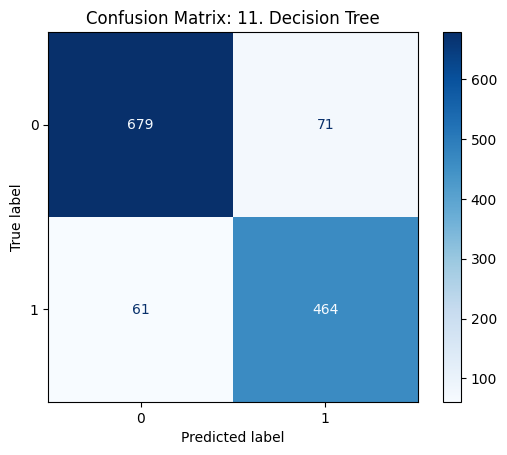

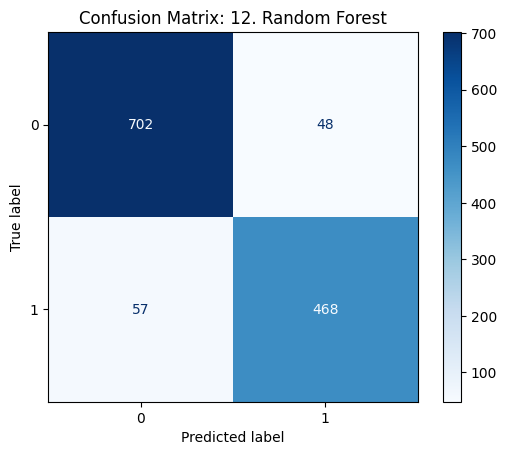

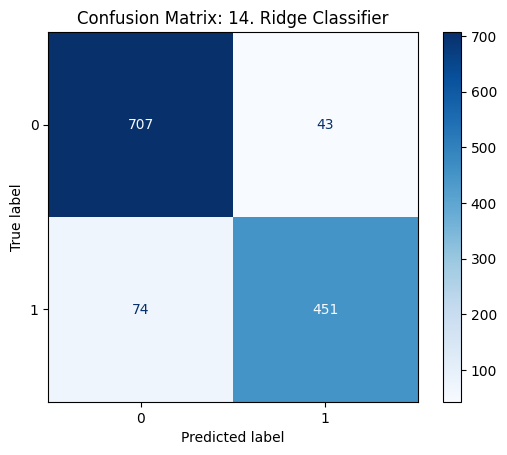

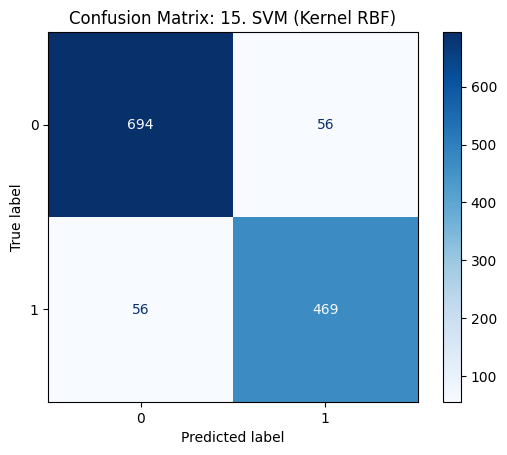

In [ ]:
""" 
  # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold_32.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
Wave_peaks, X_peaks = select_peaks(X_clean, wavenumbers)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = evaluate_models_leave_25_out(X_peaks, Y_final , class_name = ['<= 6.4 ppm (0)', '> 6.4 ppm (1)'])
""""

In [ ]:

   # 1. โหลดข้อมูล (กางตาราง)
wavenumbers, intensities, Y_labels = remove_duplicates(df_cal_Threshold_32.drop(columns=['Concentration']))

    # 2. คลีนสัญญาณเส้นเต็มก่อน (เพื่อให้ Smoothing และ Baseline ทำงานได้สมบูรณ์)
X_clean, Y_final = preprocessing(intensities, wavenumbers, Y_labels)
   # 3. cropspectra
X_peaks , Y_final = sersmap(X_clean, Y_final)
print(f"DATA:{X_peaks.shape} Y:{Y_final.shape}")
    # 4. Model
results = sers_leave_out(X_peaks, Y_final , class_name = ['<= 6.4 ppm (0)', '> 6.4 ppm (1)'])


NameError: name 'remove_duplicates' is not defined